In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from influxdb_client import InfluxDBClient
import os
from dotenv import load_dotenv
from utils import fetch_influx_data, query

Configurazione caricata correttamente!
 URL: http://192.168.135.209:8086 |  Bucket: monitoraggio_pi


In [3]:
test = fetch_influx_data( query=query)
test

,result,table,_start,_stop,_time,_measurement,host,stanza,percepita,temperatura,umidita
0,_result,0,2026-07-25 09:33:36.488961+00:00,2026-07-25 12:33:36.488961+00:00,2026-07-25 09:58:26.900228+00:00,ambiente,raspberry_pi_4,camera,27.6,28.9,26.0
1,_result,0,2026-07-25 09:33:36.488961+00:00,2026-07-25 12:33:36.488961+00:00,2026-07-25 09:58:32.213378+00:00,ambiente,raspberry_pi_4,camera,27.6,28.9,26.0
2,_result,0,2026-07-25 09:33:36.488961+00:00,2026-07-25 12:33:36.488961+00:00,2026-07-25 09:58:37.486330+00:00,ambiente,raspberry_pi_4,camera,27.6,28.9,26.0
3,_result,0,2026-07-25 09:33:36.488961+00:00,2026-07-25 12:33:36.488961+00:00,2026-07-25 09:58:42.756831+00:00,ambiente,raspberry_pi_4,camera,27.6,28.9,26.0
4,_result,0,2026-07-25 09:33:36.488961+00:00,2026-07-25 12:33:36.488961+00:00,2026-07-25 09:58:48.038372+00:00,ambiente,raspberry_pi_4,camera,27.6,28.9,26.0
...,...,...,...,...,...,...,...,...,...,...,...
1607,_result,0,2026-07-25 09:33:36.488961+00:00,2026-07-25 12:33:36.488961+00:00,2026-07-25 12:33:10.542580+00:00,ambiente,raspberry_pi_4,camera,28.5,29.7,31.0
1608,_result,0,2026-07-25 09:33:36.488961+00:00,2026-07-25 12:33:36.488961+00:00,2026-07-25 12:33:15.812118+00:00,ambiente,raspberry_pi_4,camera,28.5,29.7,31.0
1609,_result,0,2026-07-25 09:33:36.488961+00:00,2026-07-25 12:33:36.488961+00:00,2026-07-25 12:33:21.072079+00:00,ambiente,raspberry_pi_4,camera,28.5,29.6,31.0
1610,_result,0,2026-07-25 09:33:36.488961+00:00,2026-07-25 12:33:36.488961+00:00,2026-07-25 12:33:26.344269+00:00,ambiente,raspberry_pi_4,camera,28.5,29.6,31.0


In [4]:
test.to_csv("data/days/25-luglio-2026.csv")

<Axes: >

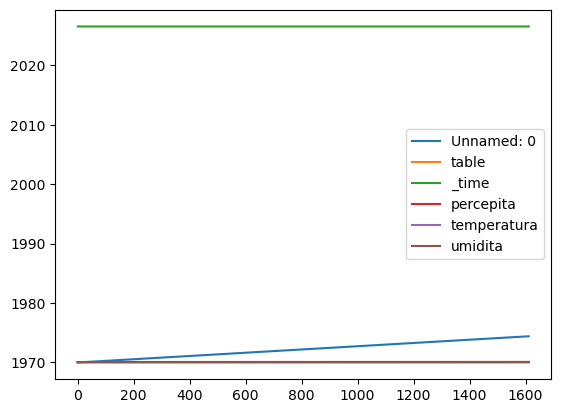

In [3]:
df = pd.read_csv("data/days/25-luglio-2026.csv", parse_dates=['_time'] )
df.plot()

/tmp/ipykernel_11163/2587655742.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


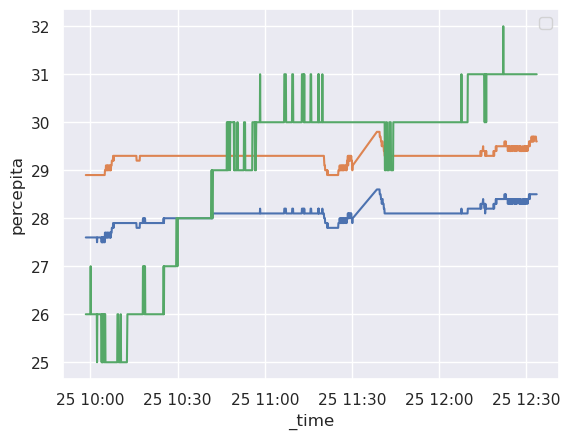

In [10]:
sns.set_theme(style="darkgrid")
sns.lineplot(x='_time', y='percepita', data=df)
sns.lineplot(x='_time', y='temperatura', data=df)
sns.lineplot(x='_time', y='umidita', data=df)
plt.legend()
plt.show()

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1612 entries, 0 to 1611
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   Unnamed: 0    1612 non-null   int64              
 1   result        1612 non-null   object             
 2   table         1612 non-null   int64              
 3   _start        1612 non-null   object             
 4   _stop         1612 non-null   object             
 5   _time         1612 non-null   datetime64[ns, UTC]
 6   _measurement  1612 non-null   object             
 7   host          1612 non-null   object             
 8   stanza        1612 non-null   object             
 9   percepita     1612 non-null   float64            
 10  temperatura   1612 non-null   float64            
 11  umidita       1612 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(3), int64(2), object(6)
memory usage: 151.3+ KB


In [19]:
reindex_df = df.set_index('_time')
reindex_df

In [23]:

reindex_df.info()



<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1612 entries, 2026-07-25 09:58:26.900228+00:00 to 2026-07-25 12:33:31.604329+00:00
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    1612 non-null   int64  
 1   result        1612 non-null   object 
 2   table         1612 non-null   int64  
 3   _start        1612 non-null   object 
 4   _stop         1612 non-null   object 
 5   _measurement  1612 non-null   object 
 6   host          1612 non-null   object 
 7   stanza        1612 non-null   object 
 8   percepita     1612 non-null   float64
 9   temperatura   1612 non-null   float64
 10  umidita       1612 non-null   float64
dtypes: float64(3), int64(2), object(6)
memory usage: 151.1+ KB


<Axes: xlabel='_time'>

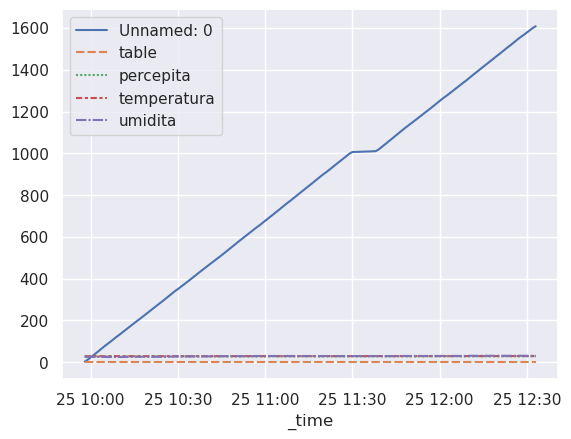

In [31]:
ttt = reindex_df.resample('min').mean('percepita').interpolate(method='linear')
sns.lineplot(data=ttt )

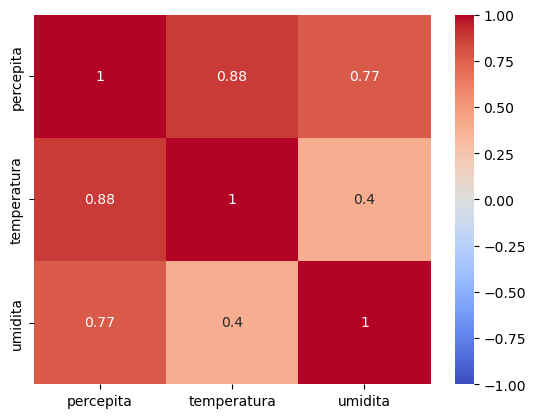

In [5]:
corr_columns = ['percepita', 'temperatura' , 'umidita']

corr_matrix  = df[corr_columns].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [6]:
corr_matrix

,percepita,temperatura,umidita
percepita,1.000000,0.875478,0.767948
temperatura,0.875478,1.000000,0.395178
umidita,0.767948,0.395178,1.000000
